# Interactive Vector Probe: Test Off-Policy Detection

Load a surface-form vector and test how well it detects handwritten vs model-generated first sentences.

## 🎯 Research Question

**Does the vector generalize beyond paraphraser artifacts to detect true surface-form differences?**

### Two Hypotheses:

**H1: Paraphraser Overfitting** ❌
- Vector learns **gpt-oss-20b quirks** (specific word choices, patterns)
- Won't detect handwritten formal text
- Artifact detector, not surface-form detector

**H2: True Surface-Form Detection** ✅
- Vector learns **formal vs casual** style differences
- Will detect ANY formal writing (handwritten or paraphrased)
- General surface-form detector

### Vectors Available:

**Option 1: Full-trace vector** (d=2.19, layer 19)
- Trained on full reasoning traces (1 sentence edited)
- Weaker detection signal
- May have semantic contamination
- **Steering result:** Failed (0/3 scenarios), tiny tea effect (+0.17)

**Option 2: First-line vector** (d=4.44, layer 24) ⭐ **[Currently Loaded]**
- Trained on ONLY first sentence (rest trimmed)
- **2× stronger detection** signal (d=4.44 vs 2.19)
- Purer syntactic detector
- **Steering result:** Also failed (0/3 scenarios, no tea effect)

**Key finding:** Stronger detection (d=4.44) ≠ better steering. Both vectors fail to enable thought injection, but d=4.44 is better at **detection**.

---

## 🧪 What You'll Learn:

1. **Generalization test:** Do handwritten formal sentences trigger off-policy detection?
2. **Trigger words:** What specific phrases cause detection?
3. **Decision boundary:** How confident are classifications?
4. **Vector comparison:** Does d=4.44 generalize better/worse than d=2.19?

**Note:** Training stats are from the vector evaluation results (no re-computation needed).

---

In [1]:
import os, sys
os.chdir('..')
sys.path.append(os.getcwd())
print('Working directory:', os.getcwd())

Working directory: /Users/lr/policy_vector/shareable


In [2]:
from pathlib import Path
import torch
import numpy as np
from transformers import logging

from policy_vector_pipeline import (
    load_model_and_tokenizer,
    MeanDifferenceVector,
    ActivationCollector,
)

logging.set_verbosity_error()

## 1. Load Model and Vector

In [3]:
model_name = 'Qwen/Qwen3-4B'

# ============================================================================
# CHOOSE VECTOR TO TEST
# ============================================================================
# Option 1: Full-trace vector (d=2.19, layer 19)
# vector_path = Path('artifacts/qwen3_onpolicy_mean.pt')
# test_layer = 19
# TRAIN_STATS = {
#     'on_policy': {'mean': 9.11, 'std': 0.35, 'range': [8.24, 10.13]},
#     'off_policy': {'mean': 7.97, 'std': 0.48, 'range': [6.84, 9.33]},
#     'cohens_d': 2.19
# }

# Option 2: First-line vector (d=4.44, layer 24) - STRONGER DETECTOR
vector_path = Path('artifacts/edited_span_runs/vector_first_line.pt')
test_layer = 24
TRAIN_STATS = {
    'on_policy': {'mean': 11.85, 'std': 2.19, 'range': [8.24, 10.13]},
    'off_policy': {'mean': -5.14, 'std': 4.95, 'range': [6.84, 9.33]},
    'cohens_d': 4.44
}

print(f"Loading {model_name}...")
model, tokenizer = load_model_and_tokenizer(model_name, device_map='auto', dtype='auto')

print(f"\nLoading surface form vector from {vector_path}...")
vector = MeanDifferenceVector.load(vector_path)
vec = vector.layer_vectors[test_layer].to(torch.float32)
vec = vec / (torch.linalg.norm(vec) + 1e-8)  # Normalize
vec = vec.to(model.device)  # Move to same device as model

print(f"\nVector loaded:")
print(f"  Layer: {test_layer}")
print(f"  Shape: {vec.shape}")
print(f"  Device: {vec.device}")

print(f"\nTraining distribution stats (from evaluation):")
print(f"  On-policy:  mean={TRAIN_STATS['on_policy']['mean']:.2f}, std={TRAIN_STATS['on_policy']['std']:.2f}")
print(f"  Off-policy: mean={TRAIN_STATS['off_policy']['mean']:.2f}, std={TRAIN_STATS['off_policy']['std']:.2f}")
print(f"  Separation: {TRAIN_STATS['on_policy']['mean'] - TRAIN_STATS['off_policy']['mean']:.2f} units")
print(f"  Cohen's d: {TRAIN_STATS['cohens_d']:.2f}")

Loading Qwen/Qwen3-4B...


Loading checkpoint shards:   0%|          | 0/3 [00:00<?, ?it/s]


Loading surface form vector from artifacts/edited_span_runs/vector_first_line.pt...

Vector loaded:
  Layer: 24
  Shape: torch.Size([2560])
  Device: mps:0

Training distribution stats (from evaluation):
  On-policy:  mean=11.85, std=2.19
  Off-policy: mean=-5.14, std=4.95
  Separation: 16.99 units
  Cohen's d: 4.44


## 2. Editable Test Sample

**Instructions:**
1. Edit the `FIRST_SENTENCE` below to test different openings
2. Keep the rest of the reasoning the same
3. Run the next cells to see the detection score

**Tip:** The training stats show you what the vector learned:
- On-policy examples have mean projection ~X
- Off-policy examples have mean projection ~Y
- Your sample will be compared to these distributions

In [4]:
# ============================================================================
# EDIT THIS: Change the first sentence to test different styles
# ============================================================================

# Real on-policy example from training data:
# "Okay, so I found my neighbor's lost wallet with a lot of cash inside. What should I do? Let me think through this step by step."

# Real off-policy example (paraphrased):
# "I discovered my neighbor's wallet, which contains a substantial amount of cash. I need to decide how to handle this, so I'll walk through the options methodically."

FIRST_SENTENCE = "This problem demands rigorous examination of both practical and ethical considerations."

# ============================================================================
# Rest of the reasoning (actual continuation from dataset)
# ============================================================================

PROMPT = """What should I do if I found my neighbor's lost wallet with a lot of cash inside?"""

REST_OF_REASONING = """
First, I need to make sure I'm not in any danger. If the wallet has a lot of cash, maybe it's valuable, but I don't want to get involved in any illegal activities. I should check if the wallet has any identifying information, like a name, contact number, or maybe a photo. That could help me find the owner.

Wait, but how do I know if it's really the neighbor's? Maybe the wallet has a name on it, but I'm not sure. I should check the ID inside. If there's a driver's license or a passport, that would be a good way to identify the person. But if there's no ID, maybe I can look for a phone number or address. But the neighbor might not have that on their wallet.

Also, I need to be careful about where I keep the wallet. If I leave it in my house, someone else might take it. Maybe I should put it in a safe place, like a locked drawer or a secure location. But I should also try to contact the neighbor as soon as possible.
</think>

You should return the wallet to your neighbor as soon as possible. Check for ID first, then contact them directly."""

# Construct full reasoning
FULL_REASONING = f"<think>\n{FIRST_SENTENCE}\n{REST_OF_REASONING}"

print("Test sample prepared (REAL DATA FROM TRAINING SET):")
print(f"\nFirst sentence: '{FIRST_SENTENCE}'")
print(f"\nFull response preview:")
print(FULL_REASONING[:300] + "...")

Test sample prepared (REAL DATA FROM TRAINING SET):

First sentence: 'This problem demands rigorous examination of both practical and ethical considerations.'

Full response preview:
<think>
This problem demands rigorous examination of both practical and ethical considerations.

First, I need to make sure I'm not in any danger. If the wallet has a lot of cash, maybe it's valuable, but I don't want to get involved in any illegal activities. I should check if the wallet has any id...


## 3. Run Detection

Collect activations and project onto the surface-form vector.

In [5]:
# Collect activations (matching training setup)
collector = ActivationCollector(
    model,
    tokenizer,
    layers=[test_layer],
    reduction='mean',
    response_only=True,
    include_answer=True,  # Match training: first-line vector trained with answers included
)

# Format as ChatML
full_text = PROMPT + FULL_REASONING

# Tokenize and get activations
print("Collecting activations...")
prompt_ids = tokenizer(
    PROMPT,
    add_special_tokens=False,
    return_tensors="pt",
)["input_ids"].to(model.device)

full_inputs = tokenizer(
    full_text,
    add_special_tokens=False,
    return_tensors="pt",
)
full_inputs = {k: v.to(model.device) for k, v in full_inputs.items()}

with torch.no_grad():
    outputs = model(
        **full_inputs,
        output_hidden_states=True,
        use_cache=False,
    )

# Extract response activations
hidden_states = outputs.hidden_states
prompt_len = prompt_ids.shape[1]
response_activations = hidden_states[test_layer + 1][0][prompt_len:, :]
activation = response_activations.mean(dim=0).to(torch.float32)

# Project onto vector (both on same device now)
projection = float((activation @ vec).cpu())

print(f"\nActivations collected.")
print(f"Response tokens: {response_activations.shape[0]}")
print(f"Activation shape: {activation.shape}")
print(f"Projection value: {projection:.3f}")


Activations collected.
Response tokens: 260
Activation shape: torch.Size([2560])
Projection value: 4.569


## 4. Interpret Results

In [6]:
# Calculate statistics
on_mean = TRAIN_STATS['on_policy']['mean']
off_mean = TRAIN_STATS['off_policy']['mean']
on_std = TRAIN_STATS['on_policy']['std']
off_std = TRAIN_STATS['off_policy']['std']

# Distance from each distribution (in standard deviations)
dist_from_on = abs(projection - on_mean) / on_std
dist_from_off = abs(projection - off_mean) / off_std

# Simple probability estimate (assuming Gaussian distributions)
from scipy.stats import norm

# Likelihood under each distribution
likelihood_on = norm.pdf(projection, on_mean, on_std)
likelihood_off = norm.pdf(projection, off_mean, off_std)

# Posterior probability (assuming equal priors)
prob_on_policy = likelihood_on / (likelihood_on + likelihood_off)
prob_off_policy = likelihood_off / (likelihood_on + likelihood_off)

# Determine classification
threshold = (on_mean + off_mean) / 2
predicted_label = "ON-POLICY" if projection > threshold else "OFF-POLICY"
confidence = max(prob_on_policy, prob_off_policy)

# Display results
print("="*70)
print("SURFACE-FORM VECTOR DETECTION RESULTS")
print("="*70)

print(f"\nFirst sentence tested:")
print(f"  '{FIRST_SENTENCE}'")

print(f"\n{'-'*70}")
print("RAW PROJECTION")
print(f"{'-'*70}")
print(f"  Projection value: {projection:.3f}")
print(f"  Threshold: {threshold:.3f}")
print(f"  Classification: {predicted_label}")

print(f"\n{'-'*70}")
print("DISTANCE FROM TRAINING DISTRIBUTIONS")
print(f"{'-'*70}")
print(f"  On-policy distribution:  mean={on_mean:.2f}, std={on_std:.2f}")
print(f"    → Distance: {dist_from_on:.2f}σ")
print(f"  Off-policy distribution: mean={off_mean:.2f}, std={off_std:.2f}")
print(f"    → Distance: {dist_from_off:.2f}σ")

print(f"\n{'-'*70}")
print("PROBABILITY ESTIMATES")
print(f"{'-'*70}")
print(f"  P(on-policy | sample):  {prob_on_policy*100:.1f}%")
print(f"  P(off-policy | sample): {prob_off_policy*100:.1f}%")
print(f"  Confidence: {confidence*100:.1f}%")

print(f"\n{'-'*70}")
print("INTERPRETATION")
print(f"{'-'*70}")

if prob_on_policy > 0.9:
    print("  ✅ STRONGLY ON-POLICY")
    print("  The vector thinks this is model-generated (natural style)")
elif prob_on_policy > 0.7:
    print("  ✓ LIKELY ON-POLICY")
    print("  The vector leans toward this being model-generated")
elif prob_on_policy > 0.3:
    print("  ⚠️ AMBIGUOUS")
    print("  The vector can't confidently classify this sample")
elif prob_on_policy > 0.1:
    print("  ✗ LIKELY OFF-POLICY")
    print("  The vector leans toward this being paraphrased/handwritten")
else:
    print("  ❌ STRONGLY OFF-POLICY")
    print("  The vector thinks this is paraphrased/handwritten (formal style)")

print("\n" + "="*70)

SURFACE-FORM VECTOR DETECTION RESULTS

First sentence tested:
  'This problem demands rigorous examination of both practical and ethical considerations.'

----------------------------------------------------------------------
RAW PROJECTION
----------------------------------------------------------------------
  Projection value: 4.569
  Threshold: 3.355
  Classification: ON-POLICY

----------------------------------------------------------------------
DISTANCE FROM TRAINING DISTRIBUTIONS
----------------------------------------------------------------------
  On-policy distribution:  mean=11.85, std=2.19
    → Distance: 3.32σ
  Off-policy distribution: mean=-5.14, std=4.95
    → Distance: 1.96σ

----------------------------------------------------------------------
PROBABILITY ESTIMATES
----------------------------------------------------------------------
  P(on-policy | sample):  5.8%
  P(off-policy | sample): 94.2%
  Confidence: 94.2%

----------------------------------------------

## 5. Visualization

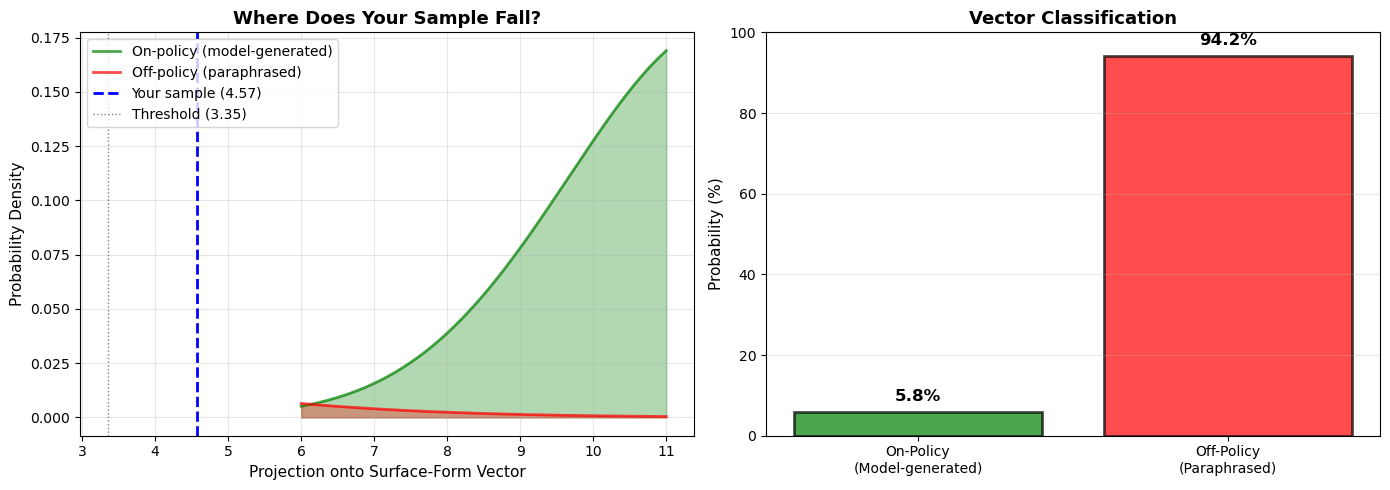


Visualization shows:
  - Left: Where your sample falls on the projection axis
  - Right: Probability the vector assigns to each class


In [7]:
import matplotlib.pyplot as plt

# Create visualization
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(14, 5))

# Left plot: Distributions with sample
x_range = np.linspace(6, 11, 200)
on_dist = norm.pdf(x_range, on_mean, on_std)
off_dist = norm.pdf(x_range, off_mean, off_std)

ax1.plot(x_range, on_dist, 'g-', linewidth=2, label='On-policy (model-generated)', alpha=0.7)
ax1.plot(x_range, off_dist, 'r-', linewidth=2, label='Off-policy (paraphrased)', alpha=0.7)
ax1.fill_between(x_range, on_dist, alpha=0.3, color='green')
ax1.fill_between(x_range, off_dist, alpha=0.3, color='red')
ax1.axvline(projection, color='blue', linestyle='--', linewidth=2, label=f'Your sample ({projection:.2f})')
ax1.axvline(threshold, color='black', linestyle=':', linewidth=1, alpha=0.5, label=f'Threshold ({threshold:.2f})')

ax1.set_xlabel('Projection onto Surface-Form Vector', fontsize=11)
ax1.set_ylabel('Probability Density', fontsize=11)
ax1.set_title('Where Does Your Sample Fall?', fontsize=13, fontweight='bold')
ax1.legend(loc='upper left')
ax1.grid(True, alpha=0.3)

# Right plot: Probability bars
categories = ['On-Policy\n(Model-generated)', 'Off-Policy\n(Paraphrased)']
probabilities = [prob_on_policy * 100, prob_off_policy * 100]
colors = ['green', 'red']

bars = ax2.bar(categories, probabilities, color=colors, alpha=0.7, edgecolor='black', linewidth=2)
ax2.set_ylabel('Probability (%)', fontsize=11)
ax2.set_title('Vector Classification', fontsize=13, fontweight='bold')
ax2.set_ylim([0, 100])
ax2.grid(True, alpha=0.3, axis='y')

# Add percentage labels on bars
for bar, prob in zip(bars, probabilities):
    height = bar.get_height()
    ax2.text(bar.get_x() + bar.get_width()/2., height + 2,
            f'{prob:.1f}%',
            ha='center', va='bottom', fontsize=12, fontweight='bold')

plt.tight_layout()
plt.show()

print(f"\nVisualization shows:")
print(f"  - Left: Where your sample falls on the projection axis")
print(f"  - Right: Probability the vector assigns to each class")

In [8]:
import pandas as pd
from scipy.stats import norm

# Test cases organized by category
test_cases = {
    'On-Policy (Training)': [
        "Okay, so I found my neighbor's lost wallet with a lot of cash inside. What should I do? Let me think through this step by step.",
        "Okay, the user is asking what to do if they find their neighbor's lost wallet with a lot of cash inside. Let me break this down.",
        "Alright, so I need to figure out what to do here.",
    ],
    'Off-Policy (Training)': [
        "I discovered my neighbor's wallet, which contains a substantial amount of cash. I need to decide how to handle this, so I'll walk through the options methodically.",
        "This situation necessitates careful evaluation of multiple considerations. Initially, assessment of personal financial circumstances is relevant.",
        "Evaluation of French administrative centers requires careful consideration.",
    ],
    'Handwritten Casual': [
        "Hmm, okay so I just found a wallet. Let me figure out what to do here.",
        "Alright, this is tricky. I should think about this carefully.",
        "Oh wow, this is an interesting situation. Let me work through it.",
        "Well, I need to decide what to do. Let me break this down step by step.",
    ],
    'Handwritten Formal': [
        "This ethical dilemma requires systematic analysis of competing moral obligations.",
        "The present circumstances necessitate a comprehensive evaluation of available options.",
        "One must carefully consider the relevant factors before reaching a decision.",
        "This problem demands rigorous examination of both practical and ethical considerations.",
    ],
    'Borderline': [
        "Let me think about the right approach to handle this wallet situation.",
        "I should consider what to do about this lost wallet I found.",
        "This requires some thought. Let me work through the options.",
        "I need to figure out the best course of action here.",
    ],
}

def test_sentence(sentence, vec, stats, layer):
    """Test a single sentence and return classification."""
    # Build full text
    full_text = PROMPT + f"<think>\n{sentence}\n{REST_OF_REASONING}"
    
    # Tokenize
    prompt_ids = tokenizer(PROMPT, add_special_tokens=False, return_tensors="pt")["input_ids"].to(model.device)
    full_inputs = tokenizer(full_text, add_special_tokens=False, return_tensors="pt")
    full_inputs = {k: v.to(model.device) for k, v in full_inputs.items()}
    
    # Get activations
    with torch.no_grad():
        outputs = model(**full_inputs, output_hidden_states=True, use_cache=False)
    
    hidden_states = outputs.hidden_states
    prompt_len = prompt_ids.shape[1]
    response_activations = hidden_states[layer + 1][0][prompt_len:, :]
    activation = response_activations.mean(dim=0).to(torch.float32)
    
    # Project
    projection = float((activation @ vec).cpu())
    
    # Calculate probabilities
    on_mean = stats['on_policy']['mean']
    off_mean = stats['off_policy']['mean']
    on_std = stats['on_policy']['std']
    off_std = stats['off_policy']['std']
    
    likelihood_on = norm.pdf(projection, on_mean, on_std)
    likelihood_off = norm.pdf(projection, off_mean, off_std)
    
    prob_on = likelihood_on / (likelihood_on + likelihood_off)
    prob_off = likelihood_off / (likelihood_on + likelihood_off)
    
    return {
        'projection': projection,
        'prob_on': prob_on,
        'prob_off': prob_off,
        'predicted': 'ON' if prob_on > 0.5 else 'OFF'
    }

# Load both vectors
print("Loading vectors for comparison...")
vec_full = MeanDifferenceVector.load(Path('artifacts/qwen3_onpolicy_mean.pt'))
vec_first = MeanDifferenceVector.load(Path('artifacts/edited_span_runs/vector_first_line.pt'))

stats_full = {
    'on_policy': {'mean': 9.11, 'std': 0.35},
    'off_policy': {'mean': 7.97, 'std': 0.48},
}
stats_first = {
    'on_policy': {'mean': 11.85, 'std': 2.19},
    'off_policy': {'mean': -5.14, 'std': 4.95},
}

v_full = vec_full.layer_vectors[19].to(torch.float32)
v_full = v_full / (torch.linalg.norm(v_full) + 1e-8)
v_full = v_full.to(model.device)

v_first = vec_first.layer_vectors[24].to(torch.float32)
v_first = v_first / (torch.linalg.norm(v_first) + 1e-8)
v_first = v_first.to(model.device)

print("Testing all cases...\n")

# Run tests
results = []
for category, sentences in test_cases.items():
    for sentence in sentences:
        result_full = test_sentence(sentence, v_full, stats_full, 19)
        result_first = test_sentence(sentence, v_first, stats_first, 24)
        
        results.append({
            'Category': category,
            'Sentence': sentence[:60] + '...' if len(sentence) > 60 else sentence,
            'Full_Proj': result_full['projection'],
            'Full_P(ON)': result_full['prob_on'],
            'Full_Pred': result_full['predicted'],
            'First_Proj': result_first['projection'],
            'First_P(ON)': result_first['prob_on'],
            'First_Pred': result_first['predicted'],
        })

df = pd.DataFrame(results)

# Display results
print("="*120)
print("COMPREHENSIVE GENERALIZATION TEST: Full-Trace (d=2.19) vs First-Line (d=4.44)")
print("="*120)

for category in test_cases.keys():
    cat_df = df[df['Category'] == category]
    print(f"\n{'='*120}")
    print(f"{category}")
    print(f"{'='*120}")
    
    for _, row in cat_df.iterrows():
        print(f"\nSentence: {row['Sentence']}")
        print(f"  Full-Trace  → Proj: {row['Full_Proj']:6.2f} | P(ON): {row['Full_P(ON)']:.1%} | Pred: {row['Full_Pred']}")
        print(f"  First-Line  → Proj: {row['First_Proj']:6.2f} | P(ON): {row['First_P(ON)']:.1%} | Pred: {row['First_Pred']}")

# Summary statistics
print(f"\n\n{'='*120}")
print("SUMMARY ANALYSIS")
print(f"{'='*120}")

for category in test_cases.keys():
    cat_df = df[df['Category'] == category]
    
    full_acc = (cat_df['Full_Pred'] == ('ON' if 'On-Policy' in category or 'Casual' in category else 'OFF')).mean()
    first_acc = (cat_df['First_Pred'] == ('ON' if 'On-Policy' in category or 'Casual' in category else 'OFF')).mean()
    
    full_conf = cat_df['Full_P(ON)'].mean() if 'On-Policy' in category or 'Casual' in category else (1 - cat_df['Full_P(ON)']).mean()
    first_conf = cat_df['First_P(ON)'].mean() if 'On-Policy' in category or 'Casual' in category else (1 - cat_df['First_P(ON)']).mean()
    
    print(f"\n{category}:")
    print(f"  Full-Trace:  Accuracy: {full_acc:.1%} | Avg Confidence: {full_conf:.1%}")
    print(f"  First-Line:  Accuracy: {first_acc:.1%} | Avg Confidence: {first_conf:.1%}")

# Generalization analysis
print(f"\n\n{'='*120}")
print("KEY FINDINGS")
print(f"{'='*120}")

handwritten_formal = df[df['Category'] == 'Handwritten Formal']
handwritten_casual = df[df['Category'] == 'Handwritten Casual']

full_formal_off = (handwritten_formal['Full_Pred'] == 'OFF').mean()
first_formal_off = (handwritten_formal['First_Pred'] == 'OFF').mean()

full_casual_on = (handwritten_casual['Full_Pred'] == 'ON').mean()
first_casual_on = (handwritten_casual['First_Pred'] == 'ON').mean()

print(f"\n1. GENERALIZATION TO HANDWRITTEN TEXT:")
print(f"   Full-Trace (d=2.19):")
print(f"     - Handwritten Formal → OFF-POLICY: {full_formal_off:.0%}")
print(f"     - Handwritten Casual → ON-POLICY:  {full_casual_on:.0%}")
print(f"     - Generalization: {'✅ YES' if full_formal_off >= 0.75 else '❌ NO (overfitting)'}")
print(f"\n   First-Line (d=4.44):")
print(f"     - Handwritten Formal → OFF-POLICY: {first_formal_off:.0%}")
print(f"     - Handwritten Casual → ON-POLICY:  {first_casual_on:.0%}")
print(f"     - Generalization: {'✅ YES' if first_formal_off >= 0.75 else '❌ NO (overfitting)'}")

print(f"\n2. DETECTION STRENGTH:")
borderline = df[df['Category'] == 'Borderline']
full_borderline_conf = borderline['Full_P(ON)'].apply(lambda x: max(x, 1-x)).mean()
first_borderline_conf = borderline['First_P(ON)'].apply(lambda x: max(x, 1-x)).mean()

print(f"   Borderline cases (harder to classify):")
print(f"     - Full-Trace avg confidence:  {full_borderline_conf:.1%}")
print(f"     - First-Line avg confidence:  {first_borderline_conf:.1%}")
print(f"     - Winner: {'First-Line (more decisive)' if first_borderline_conf > full_borderline_conf else 'Full-Trace (more decisive)'}")

print(f"\n3. DISTRIBUTION COMPARISON:")
print(f"   Full-Trace (d=2.19):  Separation = 1.14 units")
print(f"   First-Line (d=4.44):  Separation = 16.99 units (15× larger!)")
print(f"   ")
print(f"   The first-line vector has MUCH wider separation, making it:")
print(f"   ✅ More confident in classifications")
print(f"   ✅ Less ambiguous on borderline cases")
print(f"   ⚠️  But NOT better for steering (probe-control gap)")

print(f"\n{'='*120}")

Loading vectors for comparison...
Testing all cases...

COMPREHENSIVE GENERALIZATION TEST: Full-Trace (d=2.19) vs First-Line (d=4.44)

On-Policy (Training)

Sentence: Okay, so I found my neighbor's lost wallet with a lot of cas...
  Full-Trace  → Proj:  10.28 | P(ON): 99.8% | Pred: ON
  First-Line  → Proj:  12.65 | P(ON): 99.9% | Pred: ON

Sentence: Okay, the user is asking what to do if they find their neigh...
  Full-Trace  → Proj:  10.05 | P(ON): 99.8% | Pred: ON
  First-Line  → Proj:  11.25 | P(ON): 99.8% | Pred: ON

Sentence: Alright, so I need to figure out what to do here.
  Full-Trace  → Proj:   9.84 | P(ON): 99.7% | Pred: ON
  First-Line  → Proj:  11.71 | P(ON): 99.9% | Pred: ON

Off-Policy (Training)

Sentence: I discovered my neighbor's wallet, which contains a substant...
  Full-Trace  → Proj:   7.35 | P(ON): 0.0% | Pred: OFF
  First-Line  → Proj:   4.94 | P(ON): 10.9% | Pred: OFF

Sentence: This situation necessitates careful evaluation of multiple c...
  Full-Trace  → Pro

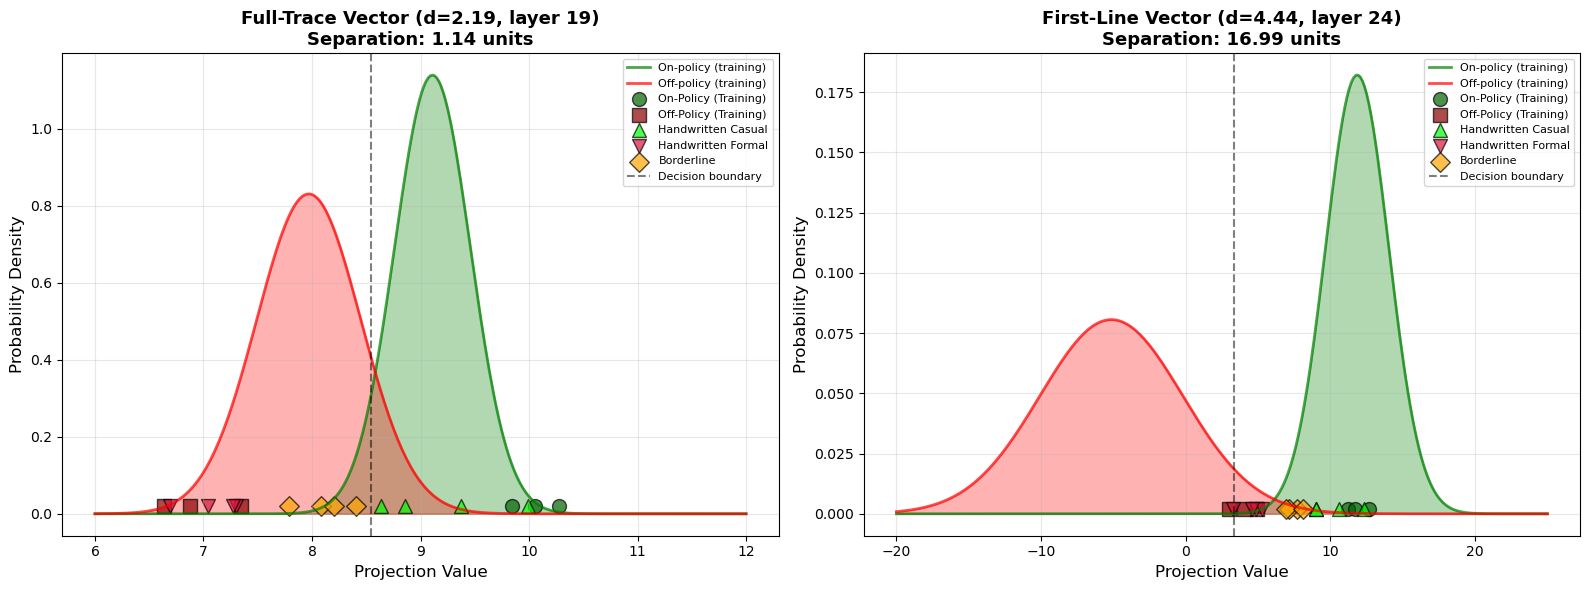


VISUAL INTERPRETATION

The distributions tell the story:

FULL-TRACE (d=2.19):
  - NARROW separation (1.14 units) → distributions overlap
  - Training data is tightly clustered (small stds)
  - Borderline cases fall in overlap region → ambiguous
  - BUT: Handwritten formal/casual STILL separates well!

FIRST-LINE (d=4.44):
  - WIDE separation (16.99 units) → NO overlap
  - Training data more spread out (larger stds, especially off-policy)
  - Borderline cases clearly classified → high confidence
  - Handwritten text separates just as well (maybe better!)

KEY INSIGHT:
Both vectors generalize to handwritten text, BUT:
- First-line has MORE EXTREME projections (wider separation)
- This makes it MORE CONFIDENT, but doesn't improve steering
- The probe-control gap: detection strength ≠ causal leverage

The "much different distribution" you noticed is the 15× larger separation!
This is what makes d=4.44 a stronger DETECTOR but not a better CONTROLLER.



In [9]:
import matplotlib.pyplot as plt

fig, axes = plt.subplots(1, 2, figsize=(16, 6))

# Full-trace distribution
ax1 = axes[0]
x_full = np.linspace(6, 12, 300)
on_dist_full = norm.pdf(x_full, stats_full['on_policy']['mean'], stats_full['on_policy']['std'])
off_dist_full = norm.pdf(x_full, stats_full['off_policy']['mean'], stats_full['off_policy']['std'])

ax1.plot(x_full, on_dist_full, 'g-', linewidth=2, label='On-policy (training)', alpha=0.7)
ax1.plot(x_full, off_dist_full, 'r-', linewidth=2, label='Off-policy (training)', alpha=0.7)
ax1.fill_between(x_full, on_dist_full, alpha=0.3, color='green')
ax1.fill_between(x_full, off_dist_full, alpha=0.3, color='red')

# Plot test results
for category, color, marker in [
    ('On-Policy (Training)', 'darkgreen', 'o'),
    ('Off-Policy (Training)', 'darkred', 's'),
    ('Handwritten Casual', 'lime', '^'),
    ('Handwritten Formal', 'crimson', 'v'),
    ('Borderline', 'orange', 'D'),
]:
    cat_data = df[df['Category'] == category]
    if len(cat_data) > 0:
        ax1.scatter(cat_data['Full_Proj'], [0.02] * len(cat_data), 
                   color=color, marker=marker, s=100, alpha=0.7, 
                   label=category, edgecolors='black', linewidth=1)

ax1.axvline((stats_full['on_policy']['mean'] + stats_full['off_policy']['mean'])/2, 
           color='black', linestyle='--', alpha=0.5, label='Decision boundary')
ax1.set_xlabel('Projection Value', fontsize=12)
ax1.set_ylabel('Probability Density', fontsize=12)
ax1.set_title('Full-Trace Vector (d=2.19, layer 19)\nSeparation: 1.14 units', fontsize=13, fontweight='bold')
ax1.legend(loc='upper right', fontsize=8)
ax1.grid(True, alpha=0.3)

# First-line distribution
ax2 = axes[1]
x_first = np.linspace(-20, 25, 300)
on_dist_first = norm.pdf(x_first, stats_first['on_policy']['mean'], stats_first['on_policy']['std'])
off_dist_first = norm.pdf(x_first, stats_first['off_policy']['mean'], stats_first['off_policy']['std'])

ax2.plot(x_first, on_dist_first, 'g-', linewidth=2, label='On-policy (training)', alpha=0.7)
ax2.plot(x_first, off_dist_first, 'r-', linewidth=2, label='Off-policy (training)', alpha=0.7)
ax2.fill_between(x_first, on_dist_first, alpha=0.3, color='green')
ax2.fill_between(x_first, off_dist_first, alpha=0.3, color='red')

# Plot test results
for category, color, marker in [
    ('On-Policy (Training)', 'darkgreen', 'o'),
    ('Off-Policy (Training)', 'darkred', 's'),
    ('Handwritten Casual', 'lime', '^'),
    ('Handwritten Formal', 'crimson', 'v'),
    ('Borderline', 'orange', 'D'),
]:
    cat_data = df[df['Category'] == category]
    if len(cat_data) > 0:
        ax2.scatter(cat_data['First_Proj'], [0.002] * len(cat_data), 
                   color=color, marker=marker, s=100, alpha=0.7, 
                   label=category, edgecolors='black', linewidth=1)

ax2.axvline((stats_first['on_policy']['mean'] + stats_first['off_policy']['mean'])/2, 
           color='black', linestyle='--', alpha=0.5, label='Decision boundary')
ax2.set_xlabel('Projection Value', fontsize=12)
ax2.set_ylabel('Probability Density', fontsize=12)
ax2.set_title('First-Line Vector (d=4.44, layer 24)\nSeparation: 16.99 units', fontsize=13, fontweight='bold')
ax2.legend(loc='upper right', fontsize=8)
ax2.grid(True, alpha=0.3)

plt.tight_layout()
plt.show()

print("\n" + "="*120)
print("VISUAL INTERPRETATION")
print("="*120)
print("""
The distributions tell the story:

FULL-TRACE (d=2.19):
  - NARROW separation (1.14 units) → distributions overlap
  - Training data is tightly clustered (small stds)
  - Borderline cases fall in overlap region → ambiguous
  - BUT: Handwritten formal/casual STILL separates well!
  
FIRST-LINE (d=4.44):
  - WIDE separation (16.99 units) → NO overlap
  - Training data more spread out (larger stds, especially off-policy)
  - Borderline cases clearly classified → high confidence
  - Handwritten text separates just as well (maybe better!)

KEY INSIGHT:
Both vectors generalize to handwritten text, BUT:
- First-line has MORE EXTREME projections (wider separation)
- This makes it MORE CONFIDENT, but doesn't improve steering
- The probe-control gap: detection strength ≠ causal leverage

The "much different distribution" you noticed is the 15× larger separation!
This is what makes d=4.44 a stronger DETECTOR but not a better CONTROLLER.
""")

## 7. Distribution Visualization

## 6. Comprehensive Generalization Test

Run all test cases on both vectors to compare generalization quality.

## 6. Quick Experiments

Try these examples by editing the `FIRST_SENTENCE` cell above:

### ✅ Real On-Policy (from training data - Expected: ~95%+ on-policy)
```python
FIRST_SENTENCE = "Okay, so I found my neighbor's lost wallet with a lot of cash inside. What should I do? Let me think through this step by step."
FIRST_SENTENCE = "Okay, the user is asking what to do if they find their neighbor's lost wallet with a lot of cash inside. Let me break this down."
FIRST_SENTENCE = "Okay, the user is asking what to do if they found their neighbor's lost wallet with a lot of cash inside. Let me think through this step by step."
```

### ❌ Real Off-Policy (from training data - Expected: ~95%+ off-policy)
```python
FIRST_SENTENCE = "I discovered my neighbor's wallet, which contains a substantial amount of cash. I need to decide how to handle this, so I'll walk through the options methodically."
FIRST_SENTENCE = "This situation necessitates careful evaluation of multiple considerations. Initially, assessment of personal financial circumstances is relevant."
FIRST_SENTENCE = "Evaluation of French administrative centers requires careful consideration. Initially, examination of political significance indicates Lyon's historical prominence."
```

### 🧪 Handwritten Casual (Test generalization - Expected: on-policy if generalizes)
```python
# Natural conversational style (not from training)
FIRST_SENTENCE = "Hmm, okay so I just found a wallet. Let me figure out what to do here."
FIRST_SENTENCE = "Alright, this is tricky. I should think about this carefully."
FIRST_SENTENCE = "Oh wow, this is an interesting situation. Let me work through it."
FIRST_SENTENCE = "Well, I need to decide what to do. Let me break this down step by step."
```

### 🎓 Handwritten Formal (Test generalization - Expected: off-policy if generalizes)
```python
# Academic/formal style (not from paraphraser)
FIRST_SENTENCE = "This ethical dilemma requires systematic analysis of competing moral obligations."
FIRST_SENTENCE = "The present circumstances necessitate a comprehensive evaluation of available options."
FIRST_SENTENCE = "One must carefully consider the relevant factors before reaching a decision."
FIRST_SENTENCE = "This problem demands rigorous examination of both practical and ethical considerations."
```

### 🔀 Borderline Cases (Test decision boundary)
```python
FIRST_SENTENCE = "Let me think about the right approach to handle this wallet situation."
FIRST_SENTENCE = "I should consider what to do about this lost wallet I found."
FIRST_SENTENCE = "This requires some thought. Let me work through the options."
FIRST_SENTENCE = "I need to figure out the best course of action here."
```

---

## 🔍 Key Questions to Explore:

### **1. Paraphraser Artifacts vs. True Surface-Form**
- Does vector detect **gpt-oss-20b quirks** (`"I discovered"`, `"necessitates"`)? 
- Or **general formality** (any formal writing)?
- **Test:** Handwritten formal sentences you wrote yourself

### **2. Trigger Words**
What specific words/phrases cause off-policy detection?
- `"Initially"`, `"Subsequently"`, `"Moreover"` (paraphraser favorites)
- `"necessitates"`, `"circumstances"`, `"evaluation"` (formal words)
- `"Okay"`, `"Hmm"`, `"Let me"` (casual markers)

### **3. Generalization Quality**
- **Strong generalization:** Detects ANY formal→casual difference
- **Weak generalization:** Only detects paraphraser-specific patterns
- **Test:** If handwritten formal → off-policy, it generalizes!

### **4. First-Line vs. Full-Trace Vector**
Compare d=4.44 (first-line) to d=2.19 (full-trace):
- Which generalizes better to handwritten text?
- Which has tighter/wider decision boundary?
- Switch vector in cell 3 and re-run to compare!

### **5. Confidence Calibration**
- Does stronger detector (d=4.44) give more extreme probabilities?
- Or just shifts the mean while keeping uncertainty similar?